In [1]:
# Bibliotecas
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # separa os dados em treino e teste

from tensorflow.keras.preprocessing.text import Tokenizer  # transforma palavras em números
from tensorflow.keras.preprocessing.sequence import pad_sequences  # padroniza o tamanho dos textos

from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.models import Model

In [8]:
df = pd.read_csv("noticias.csv")  # lê o arquivo CSV

df.head()  # mostra as cinco primeiras linhas

,categoria,texto
0,esportes,O time venceu a partida por dois gols
1,esportes,O jogador marcou o gol da vitória no campeonato
2,esportes,O campeonato começa neste domingo
3,esportes,A equipe treinou durante toda a semana
4,esportes,O atacante marcou três gols na partida


In [9]:
print("Quantidade de linhas:", len(df))  # mostra a quantidade de textos

Quantidade de linhas: 120


In [10]:
print("Colunas:", df.columns.tolist())  # mostra os nomes das colunas

Colunas: ['categoria', 'texto']


In [11]:
print(df["categoria"].value_counts())  # conta quantos textos existem em cada categoria

categoria
esportes      40
tecnologia    40
economia      40
Name: count, dtype: int64


In [12]:
df["target"] = df["categoria"].map({"esportes": 0, "tecnologia": 1, "economia": 2})  # transforma as categorias em números

print(df.head())

  categoria                                            texto  target
0  esportes            O time venceu a partida por dois gols       0
1  esportes  O jogador marcou o gol da vitória no campeonato       0
2  esportes                O campeonato começa neste domingo       0
3  esportes           A equipe treinou durante toda a semana       0
4  esportes           O atacante marcou três gols na partida       0


In [15]:
X = df["texto"].values  # textos que serão utilizados como entrada
print("Quantidade de textos:", len(X))

Quantidade de textos: 120


In [16]:
Y = df["target"].values  # categorias corretas de cada texto
print("Quantidade de respostas:", len(Y))

Quantidade de respostas: 120


In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

In [18]:
print("Textos de treino:", len(X_train))
print("Textos de teste:", len(X_test))

Textos de treino: 90
Textos de teste: 30


In [19]:
MAX_VOCAB_SIZE = 5000  # define o tamanho máximo do vocabulário

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")  # cria o tokenizador

tokenizer.fit_on_texts(X_train)  # aprende as palavras presentes nos textos de treino

In [20]:
print(tokenizer.word_index)  # mostra o índice atribuído a cada palavra

{'<OOV>': 1, 'o': 2, 'a': 3, 'de': 4, 'uma': 5, 'apresentou': 6, 'para': 7, 'novo': 8, 'com': 9, 'os': 10, 'durante': 11, 'no': 12, 'sistema': 13, 'um': 14, 'empresa': 15, 'foi': 16, 'na': 17, 'anunciou': 18, 'jogador': 19, 'partida': 20, 'crescimento': 21, 'do': 22, 'possui': 23, 'da': 24, 'equipe': 25, 'mercado': 26, 'em': 27, 'governo': 28, 'campeonato': 29, 'nova': 30, 'aumentaram': 31, 'neste': 32, 'venceu': 33, 'semana': 34, 'time': 35, 'inteligência': 36, 'artificial': 37, 'novos': 38, 'atleta': 39, 'divulgou': 40, 'dados': 41, 'sobre': 42, 'país': 43, 'nacional': 44, 'terá': 45, 'dispositivo': 46, 'vitória': 47, 'as': 48, 'trimestre': 49, 'registrou': 50, 'resultados': 51, 'jogo': 52, 'mês': 53, 'computador': 54, 'celular': 55, 'maior': 56, 'juros': 57, 'economia': 58, 'três': 59, 'aplicativo': 60, 'recebeu': 61, 'banco': 62, 'central': 63, 'encerrou': 64, 'depois': 65, 'clube': 66, 'alta': 67, 'final': 68, 'tecnologia': 69, 'marcou': 70, 'lançou': 71, 'competição': 72, 'atacan

In [21]:
sequencias_train = tokenizer.texts_to_sequences(X_train)  # transforma os textos de treino em números

sequencias_test = tokenizer.texts_to_sequences(X_test)  # transforma os textos de teste em números

print(sequencias_train[:3])  # mostra as três primeiras sequências

[[2, 28, 40, 41, 42, 2, 21, 22, 43], [2, 29, 44, 45, 5, 30, 115], [2, 46, 23, 116, 117, 9, 3, 118]]


In [26]:
MAX_LEN = 12  # define o tamanho máximo de cada texto

Xtrain = pad_sequences(sequencias_train, maxlen=MAX_LEN, padding="post")  # completa as sequências menores com zeros

Xtest = pad_sequences(sequencias_test, maxlen=MAX_LEN, padding="post")  # aplica o mesmo padrão nos textos de teste
V = len(tokenizer.word_index)

In [27]:
D = 32  # quantidade de valores utilizados para representar cada palavra
i = Input(shape=(MAX_LEN,))
x = Embedding(V + 1, D)(i)  # transforma cada palavra em um vetorx = Conv1D(64, 3, activation='relu', padding='same')(x)  # identifica padrões entre palavras
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu', padding='same')(x)  # identifica padrões entre palavras
x = GlobalMaxPooling1D()(x)  # seleciona as características mais importantes
x = Dropout(0.3)(x)  # desativa 30% dos neurônios durante o treinamento
x = Dense(3, activation='softmax')(x)  # classifica o texto em uma das três categorias

model = Model(i, x)

In [28]:
# compilação e Treino
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [29]:
r = model.fit(Xtrain, Y_train, epochs=20, validation_data=(Xtest, Y_test), batch_size=16)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3444 - loss: 1.0967 - val_accuracy: 0.4333 - val_loss: 1.0958
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4778 - loss: 1.0837 - val_accuracy: 0.4667 - val_loss: 1.0920
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5667 - loss: 1.0709 - val_accuracy: 0.4333 - val_loss: 1.0882
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6556 - loss: 1.0579 - val_accuracy: 0.5667 - val_loss: 1.0838
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7889 - loss: 1.0430 - val_accuracy: 0.6333 - val_loss: 1.0777
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8778 - loss: 1.0281 - val_accuracy: 0.6333 - val_loss: 1.0707
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8778 - loss: 1.0144 - val_accuracy: 0.6000 - val_loss: 1.0625
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9556 - loss: 0.9949 - val_accuracy: 0.7000 - val_loss: 1.0521


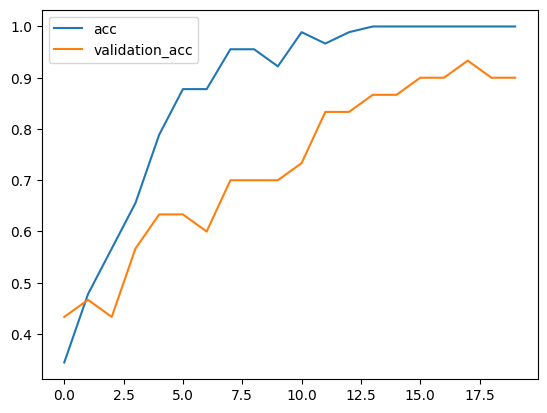

In [31]:
# grafico que mede a acuracia durante o treino e com dados que nunca viu
plt.plot(r.history['accuracy'],label='acc')
plt.plot(r.history['val_accuracy'],label='validation_acc')
plt.legend()

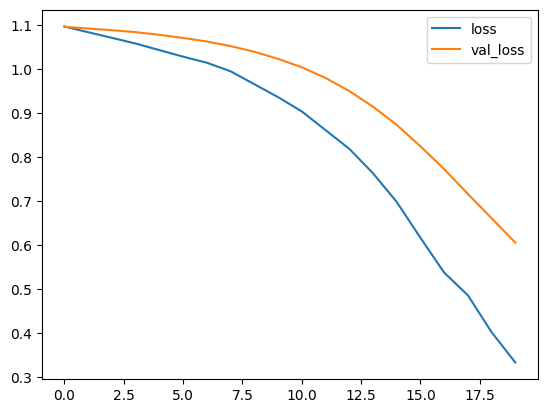

In [32]:
# grafico que mede o loss durante o treino e com dados que nunca viu
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()